# Day 27 — Economic Regime Analysis

## Objectives
- Combine economic indicators with stock-market data
- Calculate inflation and GDP growth
- Identify historical economic conditions
- Compare portfolio returns across economic regimes

In [1]:

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

conn = sqlite3.connect("hedge_fund.db")

economic = pd.read_sql_query("""
SELECT
    indicator,
    observation_date,
    available_date,
    value
FROM economic_vintages
ORDER BY indicator, observation_date, available_date
""", conn)

economic["observation_date"] = pd.to_datetime(
    economic["observation_date"]
)

economic["available_date"] = pd.to_datetime(
    economic["available_date"]
)

print("Total economic records:", len(economic))

display(
    economic.groupby("indicator")
    .agg(
        records=("value", "size"),
        first_date=("observation_date", "min"),
        latest_date=("observation_date", "max")
    )
)

Total economic records: 170


,records,first_date,latest_date
indicator,,,
CPI,66,2024-01-01,2026-08-01
FED_RATE,32,2024-01-01,2026-08-01
REAL_GDP,34,2024-01-01,2026-04-01
UNEMPLOYMENT,38,2024-01-01,2026-08-01


In [2]:

# Use the latest stored vintage of each observation.
# This is descriptive analysis, not yet a trading backtest.

latest = (
    economic
    .sort_values("available_date")
    .drop_duplicates(
        ["indicator", "observation_date"],
        keep="last"
    )
)

macro = (
    latest
    .pivot(
        index="observation_date",
        columns="indicator",
        values="value"
    )
    .sort_index()
)

# CPI: year-over-year inflation
cpi = macro["CPI"].dropna()
inflation = cpi.pct_change(12) * 100

# Real GDP: annualized quarter-over-quarter growth
gdp = macro["REAL_GDP"].dropna()
gdp_growth = (
    (gdp / gdp.shift(1)) ** 4 - 1
) * 100

print("LATEST AVAILABLE CALCULATIONS")

print("\nInflation (%):")
display(inflation.dropna().tail())

print("\nAnnualized real GDP growth (%):")
display(gdp_growth.dropna().tail())

print("\nUnemployment rate (%):")
display(macro["UNEMPLOYMENT"].dropna().tail())

print("\nFederal funds rate (%):")
display(macro["FED_RATE"].dropna().tail())

LATEST AVAILABLE CALCULATIONS

Inflation (%):


observation_date
2026-04-01    3.947027
2026-05-01    4.270033
2026-06-01    3.726530
2026-07-01    3.539751
2026-08-01    3.712958
Name: CPI, dtype: float64


Annualized real GDP growth (%):


observation_date
2025-04-01    3.838033
2025-07-01    4.375396
2025-10-01    0.482248
2026-01-01    2.089189
2026-04-01    1.483659
Name: REAL_GDP, dtype: float64


Unemployment rate (%):


observation_date
2026-04-01    4.3
2026-05-01    4.3
2026-06-01    4.2
2026-07-01    4.1
2026-08-01    4.1
Name: UNEMPLOYMENT, dtype: float64


Federal funds rate (%):


observation_date
2026-04-01    3.64
2026-05-01    3.63
2026-06-01    3.63
2026-07-01    3.63
2026-08-01    3.63
Name: FED_RATE, dtype: float64

In [3]:

# Build a descriptive monthly economic dataset

monthly = pd.DataFrame(
    index=pd.date_range(
        start="2025-01-31",
        end="2026-08-31",
        freq="ME"
    )
)

monthly["inflation_yoy"] = inflation.reindex(
    monthly.index,
    method="ffill"
)

monthly["gdp_growth"] = gdp_growth.reindex(
    monthly.index,
    method="ffill"
)

monthly["unemployment"] = (
    macro["UNEMPLOYMENT"]
    .dropna()
    .resample("ME")
    .last()
    .reindex(monthly.index)
)

monthly["fed_rate"] = (
    macro["FED_RATE"]
    .dropna()
    .resample("ME")
    .last()
    .reindex(monthly.index)
)

def classify_regime(row):
    if pd.isna(row["inflation_yoy"]) or pd.isna(row["gdp_growth"]):
        return "Insufficient data"

    if row["inflation_yoy"] >= 3 and row["gdp_growth"] < 2:
        return "High inflation / Slow growth"
    elif row["inflation_yoy"] >= 3:
        return "High inflation / Stronger growth"
    elif row["gdp_growth"] < 2:
        return "Lower inflation / Slow growth"
    else:
        return "Lower inflation / Stronger growth"

monthly["economic_regime"] = monthly.apply(
    classify_regime,
    axis=1
)

display(monthly.tail(12).round(2))
print(monthly["economic_regime"].value_counts())

,inflation_yoy,gdp_growth,unemployment,fed_rate,economic_regime
2025-09-30,3.02,4.38,4.4,4.22,High inflation / Stronger growth
2025-10-31,3.02,0.48,NaN,4.09,High inflation / Slow growth
2025-11-30,2.99,0.48,4.5,3.88,Lower inflation / Slow growth
2025-12-31,3.00,0.48,4.4,3.72,High inflation / Slow growth
2026-01-31,2.83,2.09,4.3,3.64,Lower inflation / Stronger growth
2026-02-28,2.66,2.09,4.4,3.64,Lower inflation / Stronger growth
2026-03-31,3.32,2.09,4.3,3.64,High inflation / Stronger growth
2026-04-30,3.95,1.48,4.3,3.64,High inflation / Slow growth
2026-05-31,4.27,1.48,4.3,3.63,High inflation / Slow growth
2026-06-30,3.73,1.48,4.2,3.63,High inflation / Slow growth


economic_regime
Lower inflation / Stronger growth    7
High inflation / Slow growth         7
Lower inflation / Slow growth        4
High inflation / Stronger growth     2
Name: count, dtype: int64


In [4]:

# Load the five stocks from SQLite

prices = pd.read_sql_query("""
SELECT date, ticker, close_price
FROM daily_prices
WHERE ticker IN ('AAPL', 'BLK', 'GS', 'JPM', 'MSFT')
ORDER BY date, ticker
""", conn)

prices["date"] = pd.to_datetime(prices["date"])

price_matrix = (
    prices
    .pivot(
        index="date",
        columns="ticker",
        values="close_price"
    )
    .sort_index()
)

# Equal-weight portfolio with daily rebalancing
daily_returns = price_matrix.pct_change().dropna()

portfolio_daily = daily_returns.mean(axis=1)

# Compound daily returns into monthly returns
portfolio_monthly = (
    (1 + portfolio_daily)
    .resample("ME")
    .prod()
    .sub(1)
)

print("Historical monthly portfolio returns:")
display(
    (portfolio_monthly * 100)
    .to_frame("Portfolio Return (%)")
    .tail(12)
    .round(2)
)

Historical monthly portfolio returns:


,Portfolio Return (%)
date,
2025-10-31,-0.52
2025-11-30,0.10
2025-12-31,1.74
2026-01-31,-1.78
2026-02-28,-4.21
2026-03-31,-4.31
2026-04-30,9.01
2026-05-31,5.99
2026-06-30,-4.82


,months,average_monthly_return,monthly_volatility
economic_regime,,,
High inflation / Slow growth,7,3.77,5.47
High inflation / Stronger growth,2,-1.71,3.67
Lower inflation / Slow growth,1,0.10,NaN
Lower inflation / Stronger growth,2,-2.99,1.72


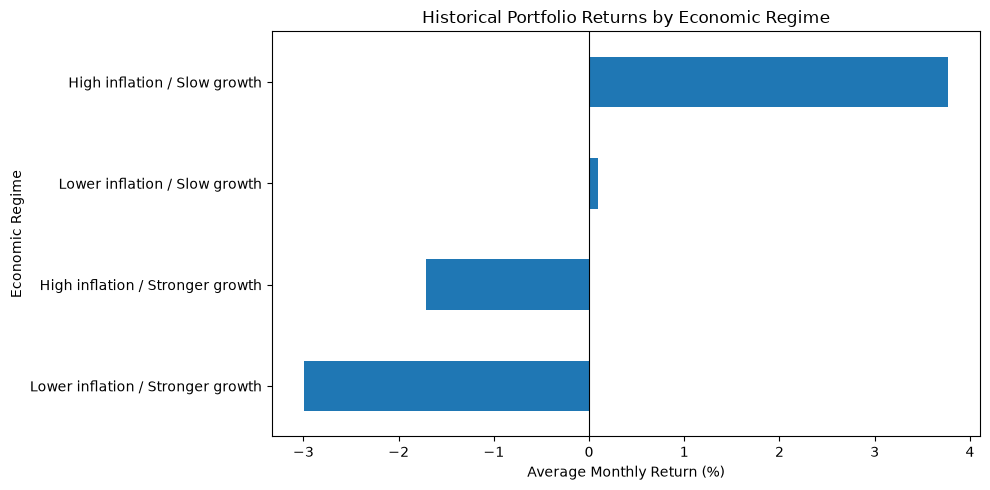

In [5]:

# Combine monthly portfolio returns with descriptive regimes

comparison = pd.DataFrame({
    "portfolio_return": portfolio_monthly
})

comparison = comparison.join(
    monthly[[
        "inflation_yoy",
        "gdp_growth",
        "economic_regime"
    ]],
    how="inner"
)

comparison = comparison[
    comparison["economic_regime"] != "Insufficient data"
].dropna(subset=["portfolio_return"])

regime_performance = (
    comparison
    .groupby("economic_regime")
    .agg(
        months=("portfolio_return", "count"),
        average_monthly_return=("portfolio_return", "mean"),
        monthly_volatility=("portfolio_return", "std")
    )
)

regime_performance[
    ["average_monthly_return", "monthly_volatility"]
] *= 100

display(regime_performance.round(2))

ax = (
    regime_performance["average_monthly_return"]
    .sort_values()
    .plot.barh(figsize=(10, 5))
)

ax.set_title("Historical Portfolio Returns by Economic Regime")
ax.set_xlabel("Average Monthly Return (%)")
ax.set_ylabel("Economic Regime")
ax.axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

In [6]:

# Check sample sizes before interpreting regime returns

quality_check = (
    comparison
    .groupby("economic_regime")
    .agg(
        months=("portfolio_return", "size"),
        mean_return=("portfolio_return", "mean"),
        median_return=("portfolio_return", "median"),
        best_month=("portfolio_return", "max"),
        worst_month=("portfolio_return", "min")
    )
)

percentage_columns = [
    "mean_return",
    "median_return",
    "best_month",
    "worst_month"
]

quality_check[percentage_columns] *= 100

display(quality_check.round(2))

if (quality_check["months"] < 6).any():
    print(
        "WARNING: At least one regime has fewer than "
        "six observations. Results are exploratory."
    )

,months,mean_return,median_return,best_month,worst_month
economic_regime,,,,,
High inflation / Slow growth,7,3.77,4.07,10.91,-4.82
High inflation / Stronger growth,2,-1.71,-1.71,0.89,-4.31
Lower inflation / Slow growth,1,0.10,0.10,0.10,0.10
Lower inflation / Stronger growth,2,-2.99,-2.99,-1.78,-4.21



## Day 27 — Findings and limitations

The five-stock portfolio's historical monthly returns were
compared across four descriptive economic regimes.

The analysis is exploratory because:
- The available stock-price history is short.
- Some regimes have very few overlapping observations.
- The economic classifications are not yet fully
  reconstructed using point-in-time release information.
- Historical associations do not establish predictive power.

Before using economic regimes in a trading backtest,
we must align each economic release with the first
eligible trading session after its availability date.